<a href="https://colab.research.google.com/github/ShaunGves/FlyRank-AI/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ShaunGves/FlyRank-AI/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
!git clone https://github.com/ShaunGves/FlyRank-AI.git
%cd FlyRank-AI

from google.colab import userdata
import os
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
print("Token loaded successfully" if os.environ["HF_TOKEN"] else "Token missing")

import duckdb, pandas as pd, os
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute("""
CREATE SECRET hf_token (
    TYPE HUGGINGFACE,
    TOKEN '{}'
);
""".format(os.environ["HF_TOKEN"]))

Cloning into 'FlyRank-AI'...
remote: Enumerating objects: 161, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (117/117), done.
remote: Total 161 (delta 64), reused 92 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (161/161), 1.90 MiB | 10.51 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/FlyRank-AI
Token loaded successfully


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

Pages are ranked by ai_opportunity_score (from the validated logistic regression model). Each gets a reason code based on where it sits on visibility and engagement: visible_engaged_page (strong on both → review_for_ai_structure), high_visibility_low_engagement (→ improve_engagement_then_review), high_engagement_low_visibility (→ monitor), or low_priority (→ no_action). This mirrors FlyRank's own archetype→action mapping style, translating a raw score into a concrete next step a human can act on.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

query_data = """
SELECT content_hash_id, gsc_impressions, gsc_avg_position, ga4_sessions, ga4_engaged_sessions, sessions_ai
FROM 'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
"""
df = con.execute(query_data).df().dropna()
df["label"] = (df["sessions_ai"] > 0).astype(int)

X = df[["gsc_impressions", "gsc_avg_position", "ga4_sessions", "ga4_engaged_sessions"]]
y = df["label"]

model = LogisticRegression(max_iter=1000).fit(X, y)
df["ai_opportunity_score"] = model.predict_proba(X)[:, 1]

# Reason codes based on signal combination
df["impr_rank"] = df["gsc_impressions"].rank(pct=True)
df["engage_rank"] = df["ga4_engaged_sessions"].rank(pct=True)

def reason_code(row):
    if row["impr_rank"] > 0.66 and row["engage_rank"] > 0.66:
        return "visible_engaged_page"
    elif row["impr_rank"] > 0.66:
        return "high_visibility_low_engagement"
    elif row["engage_rank"] > 0.66:
        return "high_engagement_low_visibility"
    else:
        return "low_priority"

df["reason_code"] = df.apply(reason_code, axis=1)

action_map = {
    "visible_engaged_page": "review_for_ai_structure",
    "high_visibility_low_engagement": "improve_engagement_then_review",
    "high_engagement_low_visibility": "monitor",
    "low_priority": "no_action"
}
df["action_label"] = df["reason_code"].map(action_map)

ranked_queue = df.sort_values("ai_opportunity_score", ascending=False)[
    ["content_hash_id", "gsc_impressions", "ga4_engaged_sessions",
     "ai_opportunity_score", "reason_code", "action_label"]
]
ranked_queue.head(10)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_hash_id,gsc_impressions,ga4_engaged_sessions,ai_opportunity_score,reason_code,action_label
8860963,content_66288edeb93b7c4f,24577,21,1.000000,visible_engaged_page,review_for_ai_structure
8054586,content_eadb33b5df496f4a,39305,15,1.000000,visible_engaged_page,review_for_ai_structure
7406798,content_eadb33b5df496f4a,33571,12,1.000000,visible_engaged_page,review_for_ai_structure
9767993,content_eadb33b5df496f4a,34606,10,1.000000,visible_engaged_page,review_for_ai_structure
9179913,content_eadb33b5df496f4a,38436,7,1.000000,visible_engaged_page,review_for_ai_structure
7050379,content_eadb33b5df496f4a,32462,10,1.000000,visible_engaged_page,review_for_ai_structure
6867135,content_eadb33b5df496f4a,32665,8,0.999999,visible_engaged_page,review_for_ai_structure
7790555,content_eadb33b5df496f4a,31713,8,0.999999,visible_engaged_page,review_for_ai_structure
9838955,content_fa4b9e9229816684,5008,16,0.999998,visible_engaged_page,review_for_ai_structure
8131920,content_eadb33b5df496f4a,31133,7,0.999995,visible_engaged_page,review_for_ai_structure


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who uses this: a content strategist or SEO manager with limited review time each week. What for: deciding which pages to review first for potential AI-visibility improvements. Where it stops being valid: this playbook only reflects patterns from month=2026-03 on one client panel — it should not be treated as valid for months or clients far outside this window without re-validation. It also stops being valid the moment someone treats a recommendation as a guarantee rather than a hypothesis to test.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting, a human must check: (1) that the page's topic is still relevant to the business (a high-scoring outdated or deprecated page isn't worth reworking); (2) that the recommended change fits the page's actual content type — not every page can add FAQ blocks meaningfully; (3) that engagement/traffic figures aren't skewed by a one-off spike (bot traffic, a viral link, etc.). What should NEVER be automated: actually rewriting or publishing content changes, deleting/pruning pages, or treating the opportunity score as a public-facing claim about a page's quality. This playbook only prioritizes review — it does not replace human judgment about what to change or whether to change it.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Signs this playbook has gone stale: (1) the underlying data month is more than a few months old relative to current traffic patterns; (2) the site's content mix has changed significantly (new page types, redesign, migration); (3) tracking gaps appear (e.g., ga4_data_available becomes False for pages that previously had data); (4) precision@K on a fresh validation month drops noticeably compared to this validation. Retrain trigger: re-run this scoring pipeline monthly, or immediately after any major site/tracking change, and re-check the honest (grouped-split) AUC before trusting a new ranked queue.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked queue is exported to work/outputs/action_playbook_queue.csv (excluded from git by design), metrics are saved to work/outputs/action_playbook_metrics.json (committed as the "receipt"), and the score distribution chart is saved to work/figures/ for reuse in the final paper.

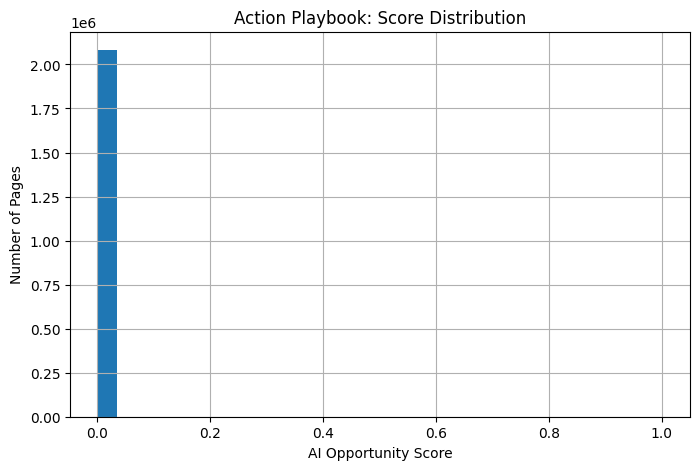

Exports complete.
{'month': '2026-03', 'num_pages_scored': 2082695, 'reason_code_counts': {'low_priority': 1367166, 'high_visibility_low_engagement': 690420, 'visible_engaged_page': 21134, 'high_engagement_low_visibility': 3975}}


In [3]:

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)

import json
metrics = {
    "month": "2026-03",
    "num_pages_scored": len(ranked_queue),
    "reason_code_counts": df["reason_code"].value_counts().to_dict()
}
with open("work/outputs/action_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
df["ai_opportunity_score"].hist(bins=30)
plt.xlabel("AI Opportunity Score")
plt.ylabel("Number of Pages")
plt.title("Action Playbook: Score Distribution")
plt.savefig("work/figures/action_playbook_score_distribution.png")
plt.show()

print("Exports complete.")
print(metrics)

## Self-check

Before you submit, confirm each line honestly:

- [ Confirm ] Every section above is filled — markdown thinking AND the code that backs it
- [ Confirm ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ Confirm ] No client names, URLs, or private queries anywhere
- [ Confirm ] My claims use careful words: observed, measured, directional, decision-support
- [ Confirm ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.